In [3]:
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [4]:
RUTA_GLOSARIO = r'C:\Users\FCEyN\Desktop\universidades scopus\Glosario Scopus.xlsx'  # ← ajustá si está en otra carpeta

glosario = pd.read_excel(RUTA_GLOSARIO, sheet_name='ASJC Classification Codes')

# Reconstruir jerarquía: asignar grupo_padre a cada fila
# Lógica: cada vez que encontramos una fila con Code=NaN, ese es el nuevo grupo padre
grupo_actual = None
glosario['grupo_padre'] = None

for idx, row in glosario.iterrows():
    if pd.isna(row['Code']):          # es un grupo padre
        grupo_actual = row['Description']
    else:                              # es un subgrupo específico
        glosario.at[idx, 'grupo_padre'] = grupo_actual

# Separar en dos tablas
# 1. Grupos padre (los 26 grupos grandes de Scopus)
grupos_padre = glosario[glosario['Code'].isna()][['Description']].copy()
grupos_padre.columns = ['Grupo']

# 2. Subgrupos específicos (los ~334 subgrupos)
subgrupos = glosario[glosario['Code'].notna()][['Code', 'Description', 'grupo_padre']].copy()
subgrupos['Code'] = subgrupos['Code'].astype(int)
subgrupos.columns = ['Code', 'Subgrupo', 'Grupo_padre']
subgrupos = subgrupos.reset_index(drop=True)

print(f"✅ Glosario cargado:")
print(f"   {len(grupos_padre)} grupos padre")
print(f"   {len(subgrupos)} subgrupos específicos")
print(f"\n📋 Los 26 grupos padre de Scopus:")
for g in grupos_padre['Grupo'].tolist():
    print(f"   - {g}")

✅ Glosario cargado:
   26 grupos padre
   334 subgrupos específicos

📋 Los 26 grupos padre de Scopus:
   - Agricultural and Biological Sciences
   - Arts and Humanities
   - Biochemistry, Genetics and Molecular Biology
   - Business, Management and Accounting
   - Chemical Engineering
   - Chemistry
   - Computer Science
   - Decision Sciences
   - Earth and Planetary Sciences
   - Economics, Econometrics and Finance
   - Energy
   - Engineering
   - Environmental Science
   - Immunology and Microbiology
   - Materials Science
   - Mathematics
   - Medicine
   - Neuroscience
   - Nursing
   - Pharmacology, Toxicology and Pharmaceutics
   - Physics and Astronomy
   - Psychology
   - Social Sciences
   - Veterinary
   - Dentistry
   - Health Professions


In [5]:
# Ver una muestra del glosario estructurado
print("Muestra del glosario estructurado:")
display(subgrupos.head(20))

# Ver cuántos subgrupos tiene cada grupo padre
print("\n📊 Subgrupos por grupo padre:")
conteo_por_grupo = subgrupos['Grupo_padre'].value_counts().sort_index()
for grupo, n in conteo_por_grupo.items():
    print(f"   {n:3d}  {grupo}")

Muestra del glosario estructurado:


,Code,Subgrupo,Grupo_padre
0,1000,Multidisciplinary,None
1,1100,General Agricultural and Biological Sciences,Agricultural and Biological Sciences
2,1101,Agricultural and Biological Sciences (miscella...,Agricultural and Biological Sciences
3,1102,Agronomy and Crop Science,Agricultural and Biological Sciences
4,1103,Animal Science and Zoology,Agricultural and Biological Sciences
5,1104,Aquatic Science,Agricultural and Biological Sciences
6,1105,"Ecology, Evolution, Behavior and Systematics",Agricultural and Biological Sciences
7,1106,Food Science,Agricultural and Biological Sciences
8,1107,Forestry,Agricultural and Biological Sciences
9,1108,Horticulture,Agricultural and Biological Sciences



📊 Subgrupos por grupo padre:
    12  Agricultural and Biological Sciences
    14  Arts and Humanities
    16  Biochemistry, Genetics and Molecular Biology
    11  Business, Management and Accounting
     9  Chemical Engineering
     8  Chemistry
    13  Computer Science
     5  Decision Sciences
     7  Dentistry
    14  Earth and Planetary Sciences
     4  Economics, Econometrics and Finance
     6  Energy
    17  Engineering
    13  Environmental Science
    17  Health Professions
     7  Immunology and Microbiology
     9  Materials Science
    15  Mathematics
    49  Medicine
    10  Neuroscience
    24  Nursing
     6  Pharmacology, Toxicology and Pharmaceutics
    11  Physics and Astronomy
     8  Psychology
    23  Social Sciences
     5  Veterinary


In [6]:
MAPEO_GRUPOS_PADRE = {
    # Grupo padre Scopus                         : ('Vertical', 'Descripción de oportunidad')
    'Agricultural and Biological Sciences'       : ('Agritech & Biotech',                     'Agronomía, cultivos, biotech agrícola, Argentina 3er productor mundial agro-biotech'),
    'Arts and Humanities'                        : ('Sin vertical industrial directa',         'Humanidades, historia, filosofía — sin vertiente industrial inmediata'),
    'Biochemistry, Genetics and Molecular Biology': ('Biotecnología & Salud',                  'Biología molecular, genética, base para farma, diagnóstico, biotech clínica'),
    'Business, Management and Accounting'        : ('Sin vertical industrial directa',         'Gestión, contabilidad — relevante para transferencia tecnológica pero no vertical central'),
    'Chemical Engineering'                       : ('Química Industrial & Procesos',           'Ingeniería química, catálisis, procesos industriales, captura CO₂, bioingeniería'),
    'Chemistry'                                  : ('Química & Materiales',                   'Química analítica, orgánica, síntesis — base para farma, materiales, agroquímicos'),
    'Computer Science'                           : ('IT & Inteligencia Artificial',            'Software, ML, IA, visión computacional, redes, procesamiento de señales'),
    'Decision Sciences'                          : ('IT & Inteligencia Artificial',            'Estadística, investigación operativa, sistemas de información para empresas'),
    'Earth and Planetary Sciences'               : ('Medioambiente & Recursos Naturales',      'Geología, geofísica, ciencias del suelo — minería, petróleo, agua, clima'),
    'Economics, Econometrics and Finance'        : ('Sin vertical industrial directa',         'Economía y finanzas — relevante para fintech pero no es fortaleza de Exactas'),
    'Energy'                                     : ('Energía & Cleantech',                     'Energía renovable, hidrógeno, nuclear, power tech — sector clave en Argentina'),
    'Engineering'                                : ('Ingeniería & Manufactura Avanzada',       'Ingeniería eléctrica, mecánica, aeroespacial, biomédica, control de sistemas'),
    'Environmental Science'                      : ('Medioambiente & Agritech',                'Ecología, cambio climático, monitoreo ambiental, agricultura sustentable'),
    'Immunology and Microbiology'                : ('Biotecnología & Salud',                   'Microbiología, virología, inmunología — base para vacunas, diagnóstico, biofarma'),
    'Materials Science'                          : ('Materiales Avanzados & Nanotecnología',   'Nanomateriales, biomateriales, polímeros, recubrimientos — manufactura, electrónica'),
    'Mathematics'                                : ('Ciencia de Datos & Modelado',             'Matemática pura y aplicada, estadística, física matemática — base para ML y IA'),
    'Medicine'                                   : ('Biotecnología & Salud',                   'Medicina clínica, farmacología, diagnóstico — potencial traslacional a biotech'),
    'Neuroscience'                               : ('Biotecnología & Salud / Neurotech',       'Neurociencias — neuroprótesis, BCI, salud mental, farmacología neurológica'),
    'Nursing'                                    : ('Sin vertical industrial directa',         'Enfermería — sin vertiente industrial directa para Exactas'),
    'Pharmacology, Toxicology and Pharmaceutics' : ('Biotecnología & Salud',                   'Descubrimiento de fármacos, toxicología, ciencia farmacéutica — Farma & Biotech'),
    'Physics and Astronomy'                      : ('Física & Tecnologías Cuánticas',          'Física básica y aplicada — quantum computing, metrología, materiales, nuclear'),
    'Psychology'                                 : ('Sin vertical industrial directa',         'Psicología — potencial en salud mental digital pero no es fortaleza central'),
    'Social Sciences'                            : ('Sin vertical industrial directa',         'Ciencias sociales — sin vertiente industrial directa para Exactas'),
    'Veterinary'                                 : ('Agritech & Biotech',                      'Veterinaria — livestock tech, biotech animal, alimentación'),
    'Dentistry'                                  : ('Sin vertical industrial directa',         'Odontología — fuera del scope de Exactas'),
    'Health Professions'                         : ('Sin vertical industrial directa',         'Profesiones de la salud — fuera del scope central de Exactas'),
}

# ═══════════════════════════════════════════════════════════════════════
#  MAPEO NIVEL 2: Subgrupos específicos → Vertical (refinamientos)
#  Solo necesitás poner acá los subgrupos donde querés una vertical
#  DIFERENTE a la que hereda de su grupo padre.
#  Usá el nombre EXACTO del subgrupo tal como figura en el glosario.
# ═══════════════════════════════════════════════════════════════════════

MAPEO_SUBGRUPOS_ESPECIFICOS = {

    'General'                                    : ('Multidisciplinario / Alto Impacto',      'Clasificación general de Scopus — papers en revistas amplias o multidisciplinarias'),

    
    # ── Código 1000 — caso especial, no tiene grupo padre ──────────────────
    'Multidisciplinary'                          : ('Multidisciplinario / Alto Impacto',      'Papers en Nature, Science, PNAS — señal de investigación de frontera'),

    
    # ── Refinamientos en Biochemistry ──────────────────────────────────
    'Biotechnology'                              : ('Agritech & Biotech',                     'Biotech aplicada: semillas, diagnostico, biosensores'),
    'Cancer Research'                            : ('Biotecnología & Salud',                  'Oncología traslacional, inmunoterapia, biomarkers'),

    # ── Refinamientos en Chemical Engineering ──────────────────────────
    'Bioengineering'                             : ('Biotecnología & Salud',                  'Bioingeniería, dispositivos médicos, biosensores de suelo'),
    'Fluid Flow and Transfer Processes'          : ('Química Industrial & Procesos',           'Ingeniería de procesos, reactores'),
    'Process Chemistry and Technology'           : ('Agritech & Biotech',                     'Procesos para agroquímicos, fertilizantes, alimentos'),

    # ── Refinamientos en Chemistry ─────────────────────────────────────
    'Analytical Chemistry'                       : ('Instrumentación & Sensores',              'Química analítica → sensores, e-tongue, detección de nutrientes'),
    'Electrochemistry'                           : ('Energía & Cleantech',                     'Electroquímica → baterías, hidrógeno, celdas de combustible'),

    # ── Refinamientos en Computer Science ──────────────────────────────
    'Artificial Intelligence'                    : ('IT & Inteligencia Artificial',            'IA/ML — fintech, industria, automatización, NLP'),
    'Computer Vision and Pattern Recognition'    : ('IT & Inteligencia Artificial',            'Visión computacional → manufactura, agricultura de precisión, seguridad'),
    'Signal Processing'                          : ('IT & Inteligencia Artificial',            'Procesamiento de señales → telecomunicaciones, biomed, audio'),
    'Computer Networks and Communications'       : ('IT & Inteligencia Artificial',            'Redes, telecomunicaciones, IoT'),

    # ── Refinamientos en Earth and Planetary Sciences ──────────────────
    'Economic Geology'                           : ('Medioambiente & Recursos Naturales',      'Geología económica → minería, litio, recursos naturales'),
    'Atmospheric Science'                        : ('Medioambiente & Agritech',                'Ciencias atmosféricas → cambio climático, modelado agroclimático'),

    # ── Refinamientos en Energy ────────────────────────────────────────
    'Nuclear Energy and Engineering'             : ('Física Nuclear & Energía',               'Nuclear → INVAP, reactores, tecnología de defensa/energía'),
    'Fuel Technology'                            : ('Energía & Cleantech',                    'Combustibles alternativos, hidrógeno, biocombustibles'),
    'Renewable Energy, Sustainability and the Environment': ('Energía & Cleantech',            'Renovables, solar, eólica, eficiencia energética'),
    'Energy Engineering and Power Technology'    : ('Energía & Cleantech',                    'Ingeniería de potencia, redes eléctricas inteligentes'),

    # ── Refinamientos en Engineering ───────────────────────────────────
    'Electrical and Electronic Engineering'      : ('Ingeniería & Manufactura Avanzada',      'Electrónica, hardware, sensores, dispositivos'),
    'Biomedical Engineering'                     : ('Biotecnología & Salud',                  'Ingeniería biomédica, dispositivos médicos, imagenología'),
    'Aerospace Engineering'                      : ('Física Nuclear & Energía',               'Aeroespacial → INVAP, satélites, cohetes'),
    'Control and Systems Engineering'            : ('IT & Inteligencia Artificial',           'Control de sistemas, automatización, robótica'),

    # ── Refinamientos en Environmental Science ─────────────────────────
    'Ecology'                                    : ('Medioambiente & Agritech',               'Ecología de agroecosistemas, biodiversidad y producción'),
    'Water Science and Technology'               : ('Medioambiente & Recursos Naturales',     'Agua — gestión hídrica, saneamiento, acuicultura'),

    # ── Refinamientos en Materials Science ────────────────────────────
    'Biomaterials'                               : ('Biotecnología & Salud',                  'Biomateriales → implantes, drug delivery, biotech'),
    'Electronic, Optical and Magnetic Materials' : ('Materiales Avanzados & Nanotecnología',  'Materiales para electrónica y quantum hardware'),
    'Surfaces, Coatings and Films'               : ('Materiales Avanzados & Nanotecnología',  'Películas delgadas, PVD, recubrimientos industriales'),

    # ── Refinamientos en Mathematics ───────────────────────────────────
    'Applied Mathematics'                        : ('Ciencia de Datos & Modelado',            'Matemática aplicada → optimización, ML, fintech, física computacional'),
    'Mathematical Physics'                       : ('Física & Tecnologías Cuánticas',         'Física matemática, metrología cuántica'),
    'Statistics and Probability'                 : ('Ciencia de Datos & Modelado',            'Estadística → data science, bioestadística, finanzas'),

    # ── Refinamientos en Physics and Astronomy ─────────────────────────
    'Nuclear and High Energy Physics'            : ('Física Nuclear & Energía',               'Física de altas energías (ATLAS/CERN) → nuclear, defensa, detectores'),
    'Condensed Matter Physics'                   : ('Materiales Avanzados & Nanotecnología',  'Materia condensada → superconductores, quantum, nuevos materiales'),
    'Statistical and Nonlinear Physics'          : ('Ciencia de Datos & Modelado',            'Física estadística, sistemas complejos, redes → fintech, bio, clima'),
    'Atomic and Molecular Physics, and Optics'   : ('Física & Tecnologías Cuánticas',         'Óptica cuántica, láseres, metrología de precisión'),
    'Instrumentation'                            : ('Instrumentación & Sensores',             'Instrumentación científica → sensores industriales, e-tongue, agro'),
    'Radiation'                                  : ('Física Nuclear & Energía',               'Radiación → medicina nuclear, radioprotección, INVAP'),

    # ── Refinamientos en Pharmacology ──────────────────────────────────
    'Drug Discovery'                             : ('Biotecnología & Salud',                  'Descubrimiento de fármacos → biofarma, química medicinal'),


    
    # ═══ AGREGÁ ACÁ refinamientos adicionales que necesites ═══════════
    # 'Nombre exacto del subgrupo': ('Vertical', 'Descripción'),
}

print(f"✅ Mapeo definido:")
print(f"   {len(MAPEO_GRUPOS_PADRE)} grupos padre mapeados")
print(f"   {len(MAPEO_SUBGRUPOS_ESPECIFICOS)} refinamientos de subgrupos específicos")

✅ Mapeo definido:
   26 grupos padre mapeados
   38 refinamientos de subgrupos específicos


In [7]:
def asignar_vertical(row):
    """
    Para un subgrupo dado, devuelve su vertical y descripción.
    Prioridad: mapeo específico > mapeo del grupo padre.
    """
    subgrupo   = row['Subgrupo']
    grupo_padre = row['Grupo_padre']

    # Primero buscamos en el mapeo específico
    if subgrupo in MAPEO_SUBGRUPOS_ESPECIFICOS:
        vertical, desc = MAPEO_SUBGRUPOS_ESPECIFICOS[subgrupo]
        fuente = 'específico'
    # Si no, usamos el grupo padre
    elif grupo_padre in MAPEO_GRUPOS_PADRE:
        vertical, desc = MAPEO_GRUPOS_PADRE[grupo_padre]
        fuente = 'heredado'
    else:
        vertical, desc, fuente = 'Sin mapear', '', 'sin mapear'

    return pd.Series({'Vertical': vertical, 'Descripcion': desc, 'Fuente_mapeo': fuente})

# Aplicar a todo el glosario
mapeo_completo = subgrupos.copy()
mapeo_completo[['Vertical', 'Descripcion', 'Fuente_mapeo']] = mapeo_completo.apply(asignar_vertical, axis=1)

print("✅ Tabla de mapeo completa generada")
print(f"   Total subgrupos: {len(mapeo_completo)}")
print(f"   Con mapeo específico: {(mapeo_completo['Fuente_mapeo']=='específico').sum()}")
print(f"   Heredados del padre: {(mapeo_completo['Fuente_mapeo']=='heredado').sum()}")
print(f"   Sin mapear: {(mapeo_completo['Fuente_mapeo']=='sin mapear').sum()}")

print("\n📊 Subgrupos por vertical:")
print(mapeo_completo['Vertical'].value_counts().to_string())

# Vista previa de la tabla
display(mapeo_completo.head(15))

✅ Tabla de mapeo completa generada
   Total subgrupos: 334
   Con mapeo específico: 37
   Heredados del padre: 297
   Sin mapear: 0

📊 Subgrupos por vertical:
Vertical
Sin vertical industrial directa          108
Biotecnología & Salud                     80
Agritech & Biotech                        19
IT & Inteligencia Artificial              19
Ciencia de Datos & Modelado               15
Ingeniería & Manufactura Avanzada         14
Medioambiente & Recursos Naturales        14
Medioambiente & Agritech                  13
Biotecnología & Salud / Neurotech         10
Materiales Avanzados & Nanotecnología      9
Física & Tecnologías Cuánticas             7
Química Industrial & Procesos              7
Química & Materiales                       6
Energía & Cleantech                        6
Física Nuclear & Energía                   4
Instrumentación & Sensores                 2
Multidisciplinario / Alto Impacto          1


,Code,Subgrupo,Grupo_padre,Vertical,Descripcion,Fuente_mapeo
0,1000,Multidisciplinary,None,Multidisciplinario / Alto Impacto,"Papers en Nature, Science, PNAS — señal de inv...",específico
1,1100,General Agricultural and Biological Sciences,Agricultural and Biological Sciences,Agritech & Biotech,"Agronomía, cultivos, biotech agrícola, Argenti...",heredado
2,1101,Agricultural and Biological Sciences (miscella...,Agricultural and Biological Sciences,Agritech & Biotech,"Agronomía, cultivos, biotech agrícola, Argenti...",heredado
3,1102,Agronomy and Crop Science,Agricultural and Biological Sciences,Agritech & Biotech,"Agronomía, cultivos, biotech agrícola, Argenti...",heredado
4,1103,Animal Science and Zoology,Agricultural and Biological Sciences,Agritech & Biotech,"Agronomía, cultivos, biotech agrícola, Argenti...",heredado
5,1104,Aquatic Science,Agricultural and Biological Sciences,Agritech & Biotech,"Agronomía, cultivos, biotech agrícola, Argenti...",heredado
6,1105,"Ecology, Evolution, Behavior and Systematics",Agricultural and Biological Sciences,Agritech & Biotech,"Agronomía, cultivos, biotech agrícola, Argenti...",heredado
7,1106,Food Science,Agricultural and Biological Sciences,Agritech & Biotech,"Agronomía, cultivos, biotech agrícola, Argenti...",heredado
8,1107,Forestry,Agricultural and Biological Sciences,Agritech & Biotech,"Agronomía, cultivos, biotech agrícola, Argenti...",heredado
9,1108,Horticulture,Agricultural and Biological Sciences,Agritech & Biotech,"Agronomía, cultivos, biotech agrícola, Argenti...",heredado


In [8]:
RUTA_ARCHIVO = r'C:\Users\FCEyN\Desktop\universidades scopus\UBA base enriquecida.xlsx'  # ← cambiá esto

df = pd.read_excel(RUTA_ARCHIVO)

print(f"✅ Dataset cargado: {len(df):,} papers, {len(df.columns)} columnas")
print(f"\n📋 Columnas disponibles:")
for col in df.columns:
    print(f"   - {col}")

✅ Dataset cargado: 13,946 papers, 27 columnas

📋 Columnas disponibles:
   - Authors
   - Author full names
   - Author(s) ID
   - Title
   - Year
   - Source title
   - Link
   - Affiliations
   - Authors with affiliations
   - Abstract
   - Author Keywords
   - Index Keywords
   - Funding Texts
   - Editors
   - Publisher
   - Document Type
   - Source
   - exactas_divisiones
   - DEPARTAMENTOS
   - INSTITUTOS
   - autores
   - autores con departamentos
   - autores con institutos
   - ASJC Classification Codes
   - Grupo tematico
   - Subgrupo
   - Subgrupo especifico


In [13]:
def contar_multivalor(serie):
    """Cuenta frecuencia de valores separados por ';' en una columna."""
    counter = Counter()
    for valor in serie.dropna():
        for parte in str(valor).split(';'):
            counter[parte.strip()] += 1
    return counter

cnt_subgrupo   = contar_multivalor(df['Subgrupo'])
cnt_especifico = contar_multivalor(df['Subgrupo especifico'])

# Definir términos del glosario oficial
terminos_glosario = set(mapeo_completo['Subgrupo'].tolist()) | set(mapeo_completo['Grupo_padre'].dropna().tolist())

# Términos cubiertos = glosario oficial + lo que agregaste manualmente
terminos_cubiertos = terminos_glosario | set(MAPEO_SUBGRUPOS_ESPECIFICOS.keys())

terminos_dataset = set(cnt_subgrupo.keys()) | set(cnt_especifico.keys())
fuera_cobertura  = terminos_dataset - terminos_cubiertos

print(f"📊 Resumen de cobertura:")
print(f"   Términos únicos en tu dataset: {len(terminos_dataset)}")
print(f"   Cubiertos por el glosario:     {len(terminos_dataset - fuera_cobertura)}")

if fuera_cobertura:
    print(f"\n⚠️  {len(fuera_cobertura)} términos sin cobertura:")
    for t in sorted(fuera_cobertura):
        cnt = cnt_subgrupo.get(t, 0) + cnt_especifico.get(t, 0)
        print(f"   [{cnt:4d} papers]  '{t}'")
    print("\n   → Agregálos en MAPEO_SUBGRUPOS_ESPECIFICOS (Celda 4)")
else:
    print("\n✅ Cobertura completa — todos los términos tienen vertical asignada.")

📊 Resumen de cobertura:
   Términos únicos en tu dataset: 330
   Cubiertos por el glosario:     330

✅ Cobertura completa — todos los términos tienen vertical asignada.


In [14]:
# Construir diccionario de lookup: término → vertical
# Incluye tanto subgrupos específicos como grupos padre

LOOKUP = {}

# 1. Subgrupos específicos del glosario
for _, row in mapeo_completo.iterrows():
    LOOKUP[row['Subgrupo']] = row['Vertical']

# 2. Grupos padre directamente
for grupo, (vertical, desc) in MAPEO_GRUPOS_PADRE.items():
    LOOKUP[grupo] = vertical

# 3. Agregar términos manuales que no están en el glosario oficial
for termino, (vertical, desc) in MAPEO_SUBGRUPOS_ESPECIFICOS.items():
    if termino not in LOOKUP:
        LOOKUP[termino] = vertical

print(f"✅ Diccionario de lookup creado: {len(LOOKUP)} entradas")
print("\nEjemplos:")
ejemplos = ['Physics and Astronomy', 'Artificial Intelligence', 'Nuclear and High Energy Physics',
            'Biotechnology', 'Applied Mathematics', 'Condensed Matter Physics']
for e in ejemplos:
    print(f"   '{e}' → '{LOOKUP.get(e, 'NO ENCONTRADO')}'")

✅ Diccionario de lookup creado: 360 entradas

Ejemplos:
   'Physics and Astronomy' → 'Física & Tecnologías Cuánticas'
   'Artificial Intelligence' → 'IT & Inteligencia Artificial'
   'Nuclear and High Energy Physics' → 'Física Nuclear & Energía'
   'Biotechnology' → 'Agritech & Biotech'
   'Applied Mathematics' → 'Ciencia de Datos & Modelado'
   'Condensed Matter Physics' → 'Materiales Avanzados & Nanotecnología'


In [15]:
def obtener_verticales_paper(fila, columnas=['Subgrupo', 'Subgrupo especifico']):
    """
    Para un paper, devuelve todas sus verticales únicas concatenadas con '; '.
    Revisa Subgrupo y Subgrupo especifico y acumula verticales sin repetir.
    """
    verticales = []
    for col in columnas:
        valor = fila.get(col, '')
        if pd.isna(valor):
            continue
        for parte in str(valor).split(';'):
            termino  = parte.strip()
            vertical = LOOKUP.get(termino, None)
            if vertical and vertical not in verticales:
                verticales.append(vertical)
    return '; '.join(verticales) if verticales else 'Sin mapear'

# Aplicar al dataset completo
df['Verticales'] = df.apply(obtener_verticales_paper, axis=1)

# Expandir para contar apariciones por vertical
verticales_expandidas = (
    df['Verticales']
    .str.split('; ')
    .explode()
    .str.strip()
    .value_counts()
)

print("✅ Verticales asignadas")
print(f"Total papers: {len(df):,}")
print(f"Papers con al menos una vertical: {(df['Verticales'] != 'Sin mapear').sum():,}")
print(f"Papers sin clasificación ASJC: {(df['Verticales'] == 'Sin mapear').sum():,}")

print("\n📊 Distribución por vertical (cada paper puede contar en varias):")
total_apariciones = verticales_expandidas.sum()
for vert, cnt in verticales_expandidas.items():
    pct = 100 * cnt / total_apariciones
    print(f"   {cnt:5d} ({pct:4.1f}%)  {vert}")

✅ Verticales asignadas
Total papers: 13,946
Papers con al menos una vertical: 12,543
Papers sin clasificación ASJC: 1,403

📊 Distribución por vertical (cada paper puede contar en varias):
    5159 (22.8%)  Biotecnología & Salud
    3273 (14.5%)  Agritech & Biotech
    1861 ( 8.2%)  Física & Tecnologías Cuánticas
    1694 ( 7.5%)  Medioambiente & Recursos Naturales
    1515 ( 6.7%)  Medioambiente & Agritech
    1403 ( 6.2%)  Sin mapear
    1245 ( 5.5%)  Sin vertical industrial directa
    1114 ( 4.9%)  Química & Materiales
    1029 ( 4.5%)  Ciencia de Datos & Modelado
     830 ( 3.7%)  Ingeniería & Manufactura Avanzada
     769 ( 3.4%)  Materiales Avanzados & Nanotecnología
     649 ( 2.9%)  Biotecnología & Salud / Neurotech
     552 ( 2.4%)  IT & Inteligencia Artificial
     531 ( 2.3%)  Física Nuclear & Energía
     526 ( 2.3%)  Química Industrial & Procesos
     214 ( 0.9%)  Instrumentación & Sensores
     212 ( 0.9%)  Energía & Cleantech
      55 ( 0.2%)  Multidisciplinario / Alto I

In [16]:
# Excluimos las verticales sin relevancia industrial para el gráfico
excluir = ['Sin vertical industrial directa', 'Sin mapear']
vc_filtrado = vc[~vc.index.isin(excluir)]

fig, ax = plt.subplots(figsize=(13.2, 6))
colores = ['#1F4E79','#2E75B6','#4472C4','#70AD47','#FFC000',
           '#FF6600','#C55A11','#7030A0','#843C0C','#A9D18E','#D6E4F0']

bars = ax.barh(
    vc_filtrado.index[::-1],
    vc_filtrado.values[::-1],
    color=colores[:len(vc_filtrado)]
)
for bar in bars:
    w = bar.get_width()
    ax.text(w + max(vc_filtrado.values)*0.01, bar.get_y() + bar.get_height()/2,
            f'{int(w):,}', va='center', fontsize=9)

ax.set_xlabel('Número de papers', fontsize=10)
ax.set_title('Papers FCEN-UBA por Vertical Industrial', fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('grafico_verticales.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado como 'grafico_verticales.png'")

NameError: name 'vc' is not defined

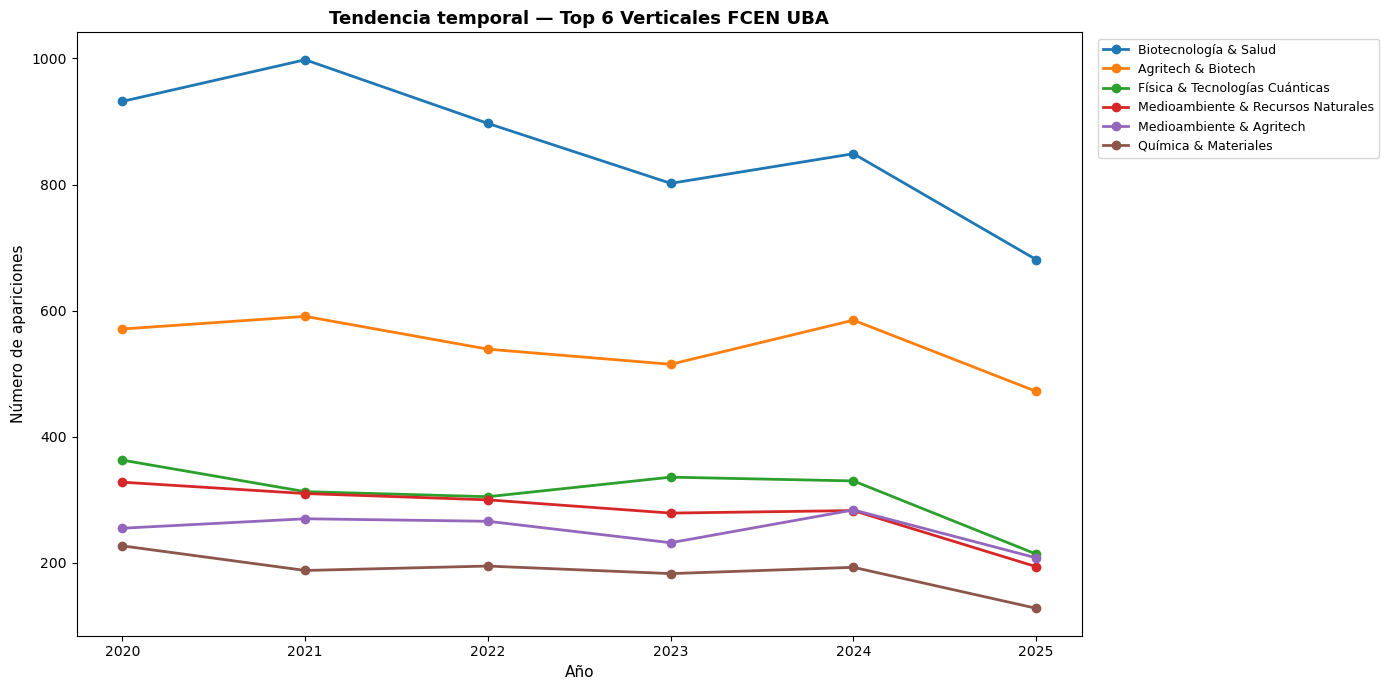

✅ Guardado como 'grafico_tendencia.png'


In [17]:
if 'Year' in df.columns:

    # Expandir verticales para el análisis temporal
    # Creamos una fila por cada combinación paper-vertical
    df_expandido = (
        df[['Year', 'Verticales']]
        .copy()
        .assign(Verticales=df['Verticales'].str.split('; '))
        .explode('Verticales')
    )
    df_expandido.columns = ['Year', 'Vertical']

    # Filtrar las que no son industriales
    excluir = ['Sin mapear', 'Sin vertical industrial directa']
    df_expandido = df_expandido[~df_expandido['Vertical'].isin(excluir)]

    # Tabla pivote: filas = año, columnas = vertical
    tabla_temporal = pd.crosstab(df_expandido['Year'], df_expandido['Vertical'])

    # Top 6 verticales por apariciones totales
    top6 = (
        verticales_expandidas
        [~verticales_expandidas.index.isin(excluir)]
        .head(6)
        .index.tolist()
    )
    cols_plot = [v for v in top6 if v in tabla_temporal.columns]

    # Gráfico
    fig, ax = plt.subplots(figsize=(14, 7))
    tabla_temporal[cols_plot].plot(ax=ax, marker='o', linewidth=2)

    ax.set_xlabel('Año', fontsize=11)
    ax.set_ylabel('Número de apariciones', fontsize=11)
    ax.set_title('Tendencia temporal — Top 6 Verticales FCEN UBA', fontsize=13, fontweight='bold')
    ax.legend(
        loc='upper left',
        bbox_to_anchor=(1.01, 1),
        fontsize=9,
        frameon=True
    )
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.savefig('grafico_tendencia.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Guardado como 'grafico_tendencia.png'")

else:
    print("⚠️  No se encontró columna 'Year'")

In [18]:
import re

# Extraer todas las afiliaciones individuales (están separadas por ';')
todas_afiliaciones = []
for val in df['Affiliations'].dropna():
    for parte in str(val).split(';'):
        todas_afiliaciones.append(parte.strip())

# Filtrar las que NO parecen académicas
# Las académicas suelen contener estas palabras
keywords_academicas = [
    # ── Español ────────────────────────────────────────────────────────
    'universidad', 'instituto', 'facultad', 'escuela', 'departamento', 'centro',
    'hospital', 'consejo', 'comision','umymfor',
    # ── Inglés ────────────────────────────────────────────────────────
    'university', 'institute', 'college', 'faculty', 'school', 'department',
    'laboratory', 'centre', 'center', 'academy', 'research council',
    # ── Francés ───────────────────────────────────────────────────────
    'université', 'école', 'laboratoire', 'observatoire',
    # ── Italiano ──────────────────────────────────────────────────────
    'università', 'istituto', 'politecnico', 'scuola',
    # ── Alemán ────────────────────────────────────────────────────────
    'universität', 'hochschule', 'technische', 'institut', 'medizinische fakultät',
    # ── Portugués ─────────────────────────────────────────────────────
    'universidade', 'faculdade', 'laboratório de instrumentacao',
    # ── Holandés/Flamenco ─────────────────────────────────────────────
    'universiteit', 'universitair',
    # ── Escandinavo ───────────────────────────────────────────────────
    'universitet', 'universitetet', 'yliopisto', 'akademin',
    # ── Eslavo ────────────────────────────────────────────────────────
    'uniwersytet', 'univerzita', 'universitatea', 'univerza',
    # ── Turco ─────────────────────────────────────────────────────────
    'üniversitesi',
    # ── Catalán/Valenciano ────────────────────────────────────────────
    'universitat',
    # ── Otros idiomas ─────────────────────────────────────────────────
    'faculté', 'ülikool', 'universitas','universiti',
    # ── Grandes laboratorios de física de partículas ───────────────────
    'conicet', 'infn', 'cern', 'triumf', 'desy', 'slac', 'fermilab',
    'national laboratory', 'laboratori nazionali', 'synchrotron',
    'high energy accelerator', 'organisation européenne pour la recherche',
    'laboratório de instrumentacao',
    # ── Observatorios y astronomía ─────────────────────────────────────
    'observator', 'observatory', 'planetar', 'osservatorio',
    'kapteyn', 'astron', 'astronomisch',
    'netherlands foundation for research in astronomy',
    # ── Institutos de investigación básica ────────────────────────────
    'max planck', 'helmholtz', 'fraunhofer', 'leibniz',
    'commissariat', 'cnrs', 'in2p3', 'cea ',
    'weizmann', 'nikhef', 'jinr',
    'institució catalana de recerca',
    'ikerbasque',
    'bruno kessler',
    'commonwealth scientific',
    'eidgenössische forschungsanstalt',
    'mascir', 'moroccan foundation for advanced science',
    'deutsches zentrum für neurodegenerative',
    'inserm', 'consiglio nazionale delle ricerche',
    # ── Hospitales universitarios europeos ────────────────────────────
    'hospital universitari', 'academic medical',
    'hôpitaux universitaires', 'hôpital universitaire',
    'leids universitair', 'maastricht universitair',
    'universitair ziekenhuis', 'universitair medisch',
    'sahlgrenska', 'erasmus mc',
    # ── Clínicas de investigación internacional ────────────────────────
    'mayo clinic', 'cleveland clinic', 'national jewish health',
    'weill cornell',
    # ── Hospitales/fundaciones internacionales no argentinas ───────────
    'fondazione', 'policlinico', 'irccs',
    'fundacao oswaldo cruz', 'fiocruz',
    'fundacion clinica medica sur',
    'fundacion santa fe de bogota',
    'fundacion neumologica colombiana',
    'hôpital', 'ziekenhuis',
    # ── Varios que se cuelan ──────────────────────────────────────────
    'eth zürich', 'eth zurich',
    'ku leuven', 'tu wien',
    'unsw', 'nyu ',
    'ithemba',
    'lip - lisboa',
    'inaf',
]

patron_academico = '|'.join(keywords_academicas)

no_academicas = [
    a for a in todas_afiliaciones
    if not re.search(patron_academico, a, re.IGNORECASE)
    and len(a) > 5  # descartar strings muy cortos
]

# Contar frecuencia
counter_no_acad = Counter(no_academicas)

print(f"Afiliaciones potencialmente no académicas: {len(counter_no_acad)} únicas")
print("\nTop 50 más frecuentes:")
for afil, cnt in counter_no_acad.most_common(50):
    print(f"   {cnt:4d}  {afil}")

Afiliaciones potencialmente no académicas: 4295 únicas

Top 50 más frecuentes:
    171  Museo Argentino de Ciencias Naturales Bernardino Rivadavia, Buenos Aires, Argentina
    131  Fundacion Para La Lucha Contra Las Enfermedades Neurologicas de La Infancia, Buenos Aires, Argentina
     84  Ministerio de Salud, Buenos Aires, Argentina
     84  Fundación Garrahan, Buenos Aires, Argentina
     69  Academia Nacional de Medicina de Buenos Aires, Buenos Aires, Argentina
     67  Servicio de Hidrografia Naval, Buenos Aires, Argentina
     50  Servicio Geologico Minero Argentino, Buenos Aires, Argentina
     48  Fundacion Favaloro, Buenos Aires, Argentina
     41  YPF Tecnología S.A., Berisso, Argentina
     41  Ministerio de Defensa República Argentina, Buenos Aires, Argentina
     40  Sanatorio Guemes, Buenos Aires, Argentina
     36  Investigación en Ciencias Veterinarias y Agronómicas, Castelar, Argentina
     34  Parques Nacionales de Argentina, Buenos Aires, Argentina
     32  Sociedad A

In [19]:
df_industria = pd.DataFrame()

if 'Affiliations' in df.columns:
    keywords_industria = [
        # ── Empresas privadas ─────────────────────────────────────────────
        'YPF Tecnología', 'Yacimientos Petrolíferos Fiscales',
        'AstraZeneca', 'Bioceres', 'Globant', 'Tenaris',
        'Mercado Libre', 'Accenture', 'IBM', 'Microsoft',
        'S\.A\.', ' Inc', ' Corp', ' Ltd', 'S\.R\.L',
        # ── Organismos públicos argentinos no académicos ───────────────────
        'Ministerio de Salud',
        'Ministerio de Defensa',
        'Servicio de Hidrografia Naval',
        'Servicio Geologico Minero Argentino',
        'Servicio Nacional de Sanidad y Calidad Agroalimentaria',
        'Parques Nacionales de Argentina',
        'Unidad de Investigacion y Desarrollo Estrategicos para la Defensa',
        'Agencia Nacional de Promoción Científica y Tecnológica',
        'INTA', 'INTI', 'SENASA',
        # ── Fundaciones y clínicas argentinas con I+D ─────────────────────
        'Fundacion Para La Lucha Contra Las Enfermedades Neurologicas',
        'Fundación Garrahan', 'Fundacion Garrahan',
        'Fundacion Favaloro',
        'Fundacion Huesped',
        'Fundacion Miguel Lillo',
        'Fundacion Pablo Cassara',
        'Fundación para el Estudio de Especies Invasivas',
        'Fundacion DAICIM',
        'Sanatorio Guemes',
        'Sanatorio de la Trinidad',
        'Sanatorio Allende',
        'Sanatorio Otamendi',
        'Sanatorio Dr\. Julio Méndez',
        'Unidad Asistencial Doctor César Milstein',
        # ── Organizaciones científicas/conservación no académicas ──────────
        'Museo Argentino de Ciencias Naturales',
        'Wildlife Conservation Society',
        'Sociedad Argentina de Diabetes',
        'Academia Nacional de Medicina de Buenos Aires',
        'Asociación Argentina de Consorcios Regionales de Experimentación Agrícola',
        'Investigación en Ciencias Veterinarias y Agronómicas',
        'Laboratorio de Entomologia',
        # ── Organismos internacionales relevantes ─────────────────────────
        'USDA Agricultural Research Service',
        'National Oceanic and Atmospheric Administration',
    ]

    patron = '|'.join(keywords_industria)
    mask = df['Affiliations'].str.contains(patron, case=False, na=False, regex=True)
    df_industria = df[mask].copy()

    # Expandir verticales igual que en el análisis principal
    df_ind_expandido = (
        df_industria[['Title', 'Year', 'Verticales', 'Affiliations']]
        .assign(Verticales=df_industria['Verticales'].str.split('; '))
        .explode('Verticales')
    )
    df_ind_expandido.columns = ['Title', 'Year', 'Vertical', 'Affiliations']

    excluir = ['Sin mapear', 'Sin vertical industrial directa']
    df_ind_expandido = df_ind_expandido[~df_ind_expandido['Vertical'].isin(excluir)]

    print(f"🏭 Papers con posible co-autoría industrial: {len(df_industria)} de {len(df)} ({100*len(df_industria)/len(df):.1f}%)")
    print("\n📊 Por vertical (conteo de apariciones):")
    print(df_ind_expandido['Vertical'].value_counts().to_string())

else:
    print("⚠️  No se encontró columna 'Affiliations'")

🏭 Papers con posible co-autoría industrial: 1419 de 13946 (10.2%)

📊 Por vertical (conteo de apariciones):
Vertical
Biotecnología & Salud                    660
Agritech & Biotech                       405
Medioambiente & Recursos Naturales       296
Medioambiente & Agritech                 175
Biotecnología & Salud / Neurotech         96
Física & Tecnologías Cuánticas            67
Ingeniería & Manufactura Avanzada         35
Química & Materiales                      34
IT & Inteligencia Artificial              22
Ciencia de Datos & Modelado               19
Materiales Avanzados & Nanotecnología     19
Química Industrial & Procesos             18
Instrumentación & Sensores                16
Física Nuclear & Energía                  14
Energía & Cleantech                       13
Multidisciplinario / Alto Impacto          8


In [21]:
def hacer_header(ws, color='1F4E79'):
    fill = PatternFill('solid', fgColor=color)
    font = Font(bold=True, color='FFFFFF', name='Arial', size=10)
    aln  = Alignment(horizontal='center', vertical='center', wrap_text=True)
    thin = Side(style='thin', color='BFBFBF')
    brd  = Border(left=thin, right=thin, top=thin, bottom=thin)
    for cell in ws[1]:
        cell.fill = fill; cell.font = font
        cell.alignment = aln; cell.border = brd
    ws.row_dimensions[1].height = 30

def escribir_df(ws, dataframe, alto=35):
    alt_fill = PatternFill('solid', fgColor='DEEAF1')
    font     = Font(name='Arial', size=9)
    aln      = Alignment(wrap_text=True, vertical='top')
    thin     = Side(style='thin', color='BFBFBF')
    brd      = Border(left=thin, right=thin, top=thin, bottom=thin)
    for c, col in enumerate(dataframe.columns, 1):
        ws.cell(1, c, col)
    hacer_header(ws)
    for r, (_, row) in enumerate(dataframe.iterrows(), 2):
        for c, val in enumerate(row, 1):
            cell = ws.cell(r, c, str(val) if pd.notna(val) else '')
            cell.font = font; cell.border = brd; cell.alignment = aln
            if r % 2 == 0:
                cell.fill = alt_fill
        ws.row_dimensions[r].height = alto

# ── Crear workbook ────────────────────────────────────────────────────
wb = Workbook()

# ── Hoja 1: Glosario completo con verticales ─────────────────────────
ws1 = wb.active
ws1.title = 'Glosario ASJC + Vertical'
glosario_export = mapeo_completo[['Code','Grupo_padre','Subgrupo','Vertical','Descripcion','Fuente_mapeo']].copy()
glosario_export.columns = ['Código ASJC','Grupo padre','Subgrupo específico','Vertical','Oportunidad industrial','Fuente del mapeo']
escribir_df(ws1, glosario_export, alto=32)
for col, w in zip(['A','B','C','D','E','F'], [12,40,48,40,60,14]):
    ws1.column_dimensions[col].width = w

# ── Hoja 2: Verticales priorizadas ───────────────────────────────────
ws2 = wb.create_sheet('Verticales Priorizadas')
excluir = ['Sin mapear', 'Sin vertical industrial directa']
resumen = (
    verticales_expandidas[~verticales_expandidas.index.isin(excluir)]
    .reset_index()
)
resumen.columns = ['Vertical', 'Apariciones']
total_apariciones = resumen['Apariciones'].sum()
resumen['% del total'] = (resumen['Apariciones'] / total_apariciones * 100).round(1).astype(str) + '%'
resumen.insert(0, 'Prioridad', ['#'+str(i+1) for i in range(len(resumen))])
verticales_desc_lookup = {row['Subgrupo']: row['Descripcion'] for _, row in mapeo_completo.iterrows()}
verticales_desc_lookup.update({k: v[1] for k, v in MAPEO_GRUPOS_PADRE.items()})
resumen['Oportunidad industrial'] = resumen['Vertical'].map(verticales_desc_lookup).fillna('')
escribir_df(ws2, resumen, alto=45)
for col, w in zip(['A','B','C','D','E'], [12,42,12,12,62]):
    ws2.column_dimensions[col].width = w

# ── Hoja 3: Dataset completo con verticales ───────────────────────────
ws3 = wb.create_sheet('Dataset con Verticales')
cols_exp = ['Title','Year','Source title','Grupo tematico','Subgrupo','Subgrupo especifico','Verticales']
cols_exp = [c for c in cols_exp if c in df.columns]
escribir_df(ws3, df[cols_exp].reset_index(drop=True), alto=30)
for col, w in zip(['A','B','C','D','E','F','G'], [52,8,32,22,42,42,58]):
    ws3.column_dimensions[col].width = w

# ── Hoja 4: Coautorías industriales ──────────────────────────────────
if not df_industria.empty:
    ws4 = wb.create_sheet('Coautorías Industriales')
    cols_ind = ['Title', 'Year', 'Verticales', 'Affiliations']
    cols_ind = [c for c in cols_ind if c in df_industria.columns]
    escribir_df(ws4, df_industria[cols_ind].reset_index(drop=True), alto=50)
    for col, w in zip(['A','B','C','D'], [52, 8, 58, 80]):
        ws4.column_dimensions[col].width = w

# ── Hoja 5: Organizaciones no académicas detectadas ──────────────────
ws5 = wb.create_sheet('Organizaciones No Académicas')

# Construir DataFrame desde el counter_no_acad generado en la celda diagnóstico
df_org = pd.DataFrame(
    counter_no_acad.most_common(),
    columns=['Organización', 'Papers con coautoría']
)
df_org.insert(0, '#', range(1, len(df_org) + 1))

# Separar país si está en la afiliación (último elemento después de la última coma)
df_org['País'] = df_org['Organización'].apply(
    lambda x: x.split(',')[-1].strip() if ',' in x else ''
)

escribir_df(ws5, df_org, alto=28)
for col, w in zip(['A','B','C','D'], [6, 70, 16, 22]):
    ws5.column_dimensions[col].width = w

# ── Guardar ───────────────────────────────────────────────────────────
NOMBRE_SALIDA = r'C:\Users\FCEyN\Desktop\universidades scopus\Verticales_FCEN_UBA_v3.xlsx'
wb.save(NOMBRE_SALIDA)
print(f"✅ Excel guardado: '{NOMBRE_SALIDA}'")
print(f"   Hojas:")
print(f"   1. Glosario ASJC + Vertical      — {len(glosario_export)} subgrupos")
print(f"   2. Verticales Priorizadas        — {len(resumen)} verticales")
print(f"   3. Dataset con Verticales        — {len(df):,} papers")
if not df_industria.empty:
    print(f"   4. Coautorías Industriales       — {len(df_industria):,} papers únicos")
print(f"   5. Organizaciones No Académicas  — {len(df_org):,} organizaciones únicas")

✅ Excel guardado: 'C:\Users\FCEyN\Desktop\universidades scopus\Verticales_FCEN_UBA_v3.xlsx'
   Hojas:
   1. Glosario ASJC + Vertical      — 334 subgrupos
   2. Verticales Priorizadas        — 16 verticales
   3. Dataset con Verticales        — 13,946 papers
   4. Coautorías Industriales       — 1,419 papers únicos
   5. Organizaciones No Académicas  — 4,295 organizaciones únicas
